In [2]:
import sys
sys.path.append('../')
import pickle

from data_generation.funcs import *

/mnt/projects/sne/Gohar/12.PROJECT_Surrogate_Dynamics/surrogate-dynamics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_file = \
    '../predict_runs/propagator/tft/cg/gaussian_regression/train_run_2/run_2/rama_data.pkl'
with open(data_file, 'rb') as f:
    data = pickle.load(f)
data['Predicted']

(array([-1.5975689, -2.3347096, -2.6618319, ..., -1.0234114, -1.8058747,
        -1.6722304], shape=(500000,), dtype=float32),
 array([ 2.8425741,  2.6255314,  2.5991445, ..., -0.0638728, -0.2614353,
        -0.6670341], shape=(500000,), dtype=float32))

Running BFGS optimizations:   0%|          | 0/200 [00:00<?, ?it/s]

Running BFGS optimizations: 100%|██████████| 200/200 [00:37<00:00,  5.36it/s]


Number of local minima found: 11
[[ 1.19931694 -2.84882999]
 [-1.36896791  2.66564711]
 [ 1.15429149  0.25259079]
 [-1.46243053 -0.34113732]
 [-2.46516983  2.81599414]
 [-1.68592008 -3.03574732]
 [ 3.04163982 -0.34899892]
 [-2.25381739 -3.00502225]
 [ 1.63918748  2.93744037]
 [ 3.03848868  2.71926655]
 [ 2.8833529  -2.91788467]]
Objective values at minima: [6.1576525  0.69921246 3.74262538 0.75774756 2.07146684 3.46102218
 5.80312525 3.55492037 7.0306976  4.88751705 7.8071112 ]
Sorted objective values at minima:
 [0.69921246 0.75774756 2.07146684 3.46102218 3.55492037 3.74262538
 4.88751705 5.80312525 6.1576525  7.0306976  7.8071112 ]
Sorted minima points:
 [[-1.36896791  2.66564711]
 [-1.46243053 -0.34113732]
 [-2.46516983  2.81599414]
 [-1.68592008 -3.03574732]
 [-2.25381739 -3.00502225]
 [ 1.15429149  0.25259079]
 [ 3.03848868  2.71926655]
 [ 3.04163982 -0.34899892]
 [ 1.19931694 -2.84882999]
 [ 1.63918748  2.93744037]
 [ 2.8833529  -2.91788467]]


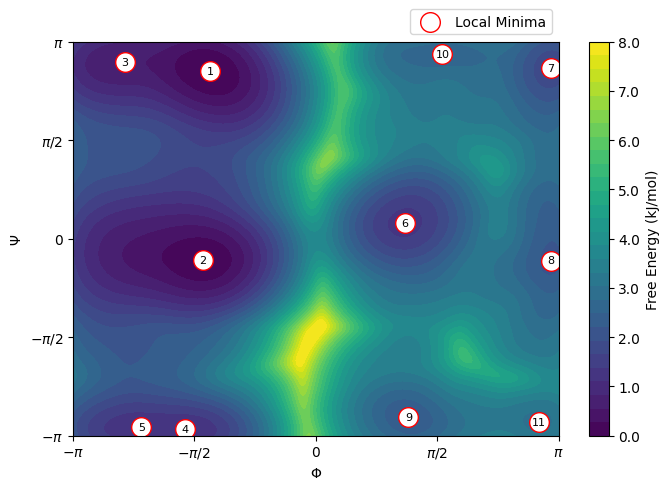

In [4]:
sigma = 0.2 # bandwidth for KDE
bin_x = 200
bin_y = 200
minima_tolerance = 0.15
n_BFGS_runs = 200
lag_time = 1


data_file = \
    '../predict_runs/propagator/tft/cg/gaussian_regression/train_run_2/run_2/rama_data.pkl'
with open(data_file, 'rb') as f:
    data = pickle.load(f)
phi, psi = data['Predicted'][0], data['Predicted'][1]
phi, psi = phi[::5], psi[::5] # subsample for faster processing

save_path = os.path.join(os.path.dirname(data_file), 'ext')

# save_path = os.path.join(run_folder, '..','population_plot.png')
# population_plot(psi, phi, save_path, save_fig=True)
# save_path = os.path.join(run_folder, '..','rama_plot.png')
# rama_plot(psi, phi, save_path, save_fig=True)
kde, min_points = run_bfgs(phi, psi, 
                        sigma, bin_x, bin_y, 
                        minima_tolerance, n_BFGS_runs)
min_points = sort_minima_by_depth(kde, min_points)
Xgrid, Ygrid, fes = compute_fes(kde, bin_x, bin_y)
plot_fes(Xgrid, Ygrid, fes, min_points, save_path=None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Computing MFPT matrix: 100%|██████████| 6/6 [00:00<00:00, 18558.87it/s]


  Shape: (6, 6)
  Lag time: 1


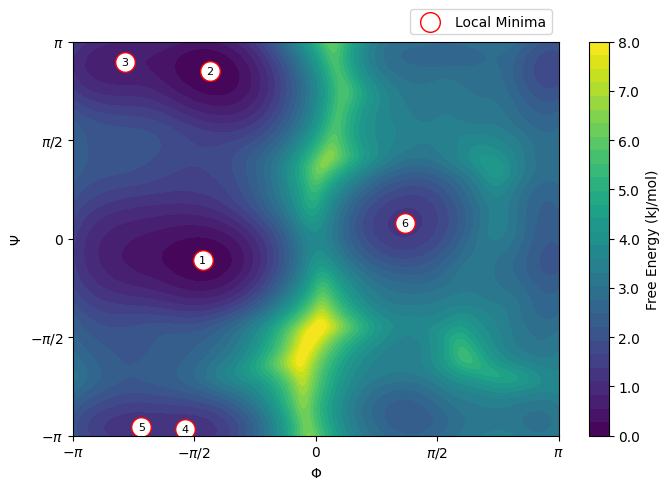

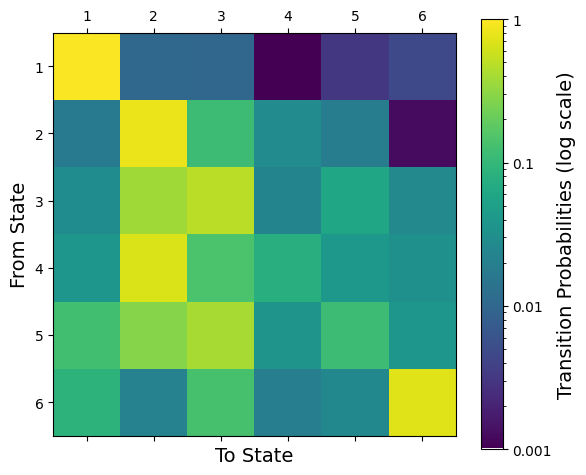

In [14]:
%load_ext autoreload
%autoreload 2
from data_generation.funcs import calculate_mfpt, plot_mfpt_matrix

selection_a = [2,1,3,4,5,6]#list(range(min(6, len(min_points))))
selection = [a-1 for a in selection_a] # convert to 0-based indexing
sel_points = min_points[selection]
os.makedirs(save_path, exist_ok=True)
save_loc = os.path.join(save_path, 'plot_fes.png')
save_loc = os.path.abspath(save_loc)
plot_fes(Xgrid, Ygrid, fes, sel_points, save_path=save_loc)
# states 
minima, transition_counts, transition_matrix, mfpt_matrix = calculate_mfpt(phi, psi, sel_points, lag_time=lag_time)
plot_mfpt_matrix(minima,
                    mfpt_matrix,
                    transition_counts,
                    transition_matrix,
                    save_path=save_path,
                    lag_time=lag_time)